# Benchmark Comparison

In [1]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, NullFormatter

PROBLEMS = [
    ("hamiltonian", "dmrg", "DMRG (TFIM)"),
    ("hamiltonian", "tdvp", "TDVP (TFIM)"),
    ("pde", "diffusion_rk4", "RK4 (Diffusion PDE)"),
]

STYLES = {
    "seemps-cython": dict(color="#1f77b4", marker="o", ls="-", linewidth=1.5, label="SeeMPS (Cython)"),
    "seemps-python": dict(color="#ff7f0e", marker="s", ls="--", linewidth=1.5, label="SeeMPS (Python)"),
    "itensors": dict(color="#2ca02c", marker="^", ls="-.", linewidth=1.5, label="ITensors.jl"),
}

# For matching LaTeX text size
FIG_WIDTH_IN = 10.0
FIG_HEIGHT_IN = 5
FONT_SIZE_PT = 12

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": FONT_SIZE_PT,
    "axes.titlesize": FONT_SIZE_PT,
    "axes.labelsize": FONT_SIZE_PT,
    "xtick.labelsize": FONT_SIZE_PT * 0.9,
    "ytick.labelsize": FONT_SIZE_PT * 0.9,
    "legend.fontsize": FONT_SIZE_PT * 0.9,
    "axes.linewidth": 0.7,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "lines.linewidth": 1.0,
    "lines.markersize": 3.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 300,
})


def read_rows(pattern="results_*.csv"):
    paths = [p for p in sorted(Path(".").glob(pattern)) if not p.name.endswith("-pre.csv")]
    if not paths:
        raise FileNotFoundError("No result CSVs found. Run the benchmarks first.")

    rows = []
    for path in paths:
        with path.open(newline="") as f:
            rows.extend(csv.DictReader(f))
    return rows


def samples(text):
    return np.array([float(x) for x in text.split(";")])


def median_iqr(text):
    q25, median, q75 = np.percentile(samples(text), [25, 50, 75])
    return median, median - q25, q75 - median


def series(rows, column):
    stats = [median_iqr(row[column]) for row in rows]
    medians, lower, upper = np.array(stats).T
    return [int(row["N"]) for row in rows], medians, [lower, upper]


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


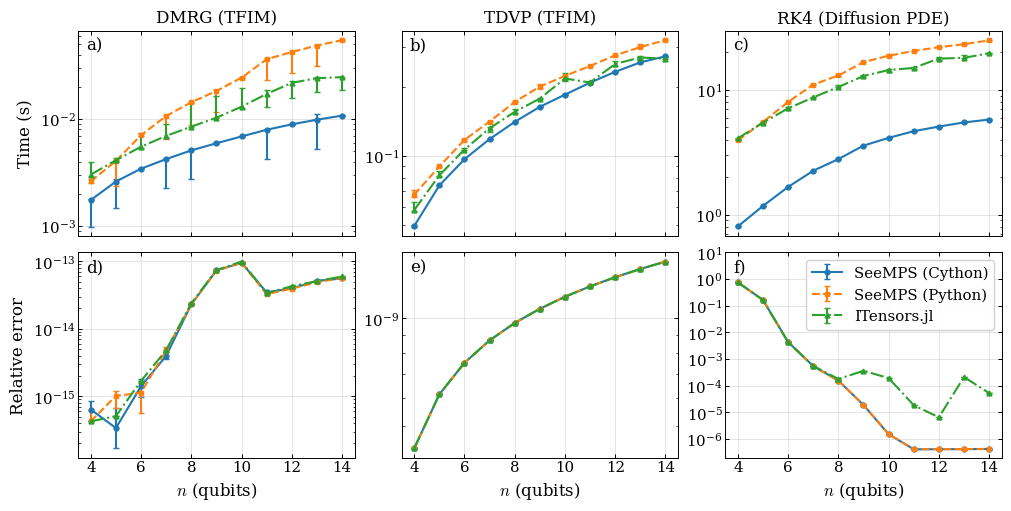

In [ ]:
rows = read_rows()
fig, axes = plt.subplots(
    2,
    len(PROBLEMS),
    figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
    sharex="col",
    layout="constrained",
)

for col, (problem, subproblem, title) in enumerate(PROBLEMS):
    ax_time, ax_error = axes[:, col]
    ax_time.set_title(title)
    ax_error.set_xlabel(r"$n$ (qubits)")

    if col == 0:
        ax_time.set_ylabel("Time (s)")
        ax_error.set_ylabel("Relative error")

    problem_rows = [
        row for row in rows
        if row["problem"] == problem and row["subproblem"] == subproblem
    ]

    for library, style in STYLES.items():
        library_rows = sorted(
            (row for row in problem_rows if row["library"] == library),
            key=lambda row: int(row["N"]),
        )
        if not library_rows:
            continue

        for ax, column in [(ax_time, "time_samples"), (ax_error, "accuracy_samples")]:
            ax.errorbar(*series(library_rows, column), capsize=2, capthick=1, **style)

for label, ax in zip("abcdef", axes.flat):
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1.0,), numticks=100))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.grid(True, which="major", color="0.85", linewidth=0.5)
    ax.tick_params(which="both", direction="in", top=True, right=True, pad=2)
    ax.text(0.03, 0.97, f"{label})", transform=ax.transAxes, va="top")

axes[1, -1].set_ylim(top=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[1, -1].legend(
    handles,
    labels,
    loc="upper right",
    frameon=True,
    framealpha=0.9,
    handlelength=2.0,
)

fig.savefig("benchmark_comparison.pdf")